Reducir estados a binarias


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import label_binarize

# TABLA FINAL

## Calculo de Y

In [2]:
data = pd.read_csv("final_data.csv")
data.reset_index()
data.shape

(97916, 26)

In [3]:
data = data[
    (data["customer_state"] != "unknown") &
    (data["seller_state"] != "unknown")
]

In [4]:
review_mapping_3 = {
    5: 2,
    4: 1,
    3: 1,
    2: 0,
    1: 0
}

review_mapping_2 = {
    5: 1,
    4: 0,
    3: 0,
    2: 0,
    1: 0
}
y_5 = data["media_review_score"]
y_3 = data["media_review_score"].map(review_mapping_3)
y_2 = data["media_review_score"].map(review_mapping_2)
data["media_review_score"] = data["media_review_score"].map(review_mapping_3)
y_dict = {"y_2":y_2,
          "y_3":y_3,
          "y_5":y_5
         }

y_dict

{'y_2': 0        1
 1        0
 2        1
 3        0
 4        1
         ..
 97911    1
 97912    1
 97913    1
 97914    1
 97915    1
 Name: media_review_score, Length: 94719, dtype: int64,
 'y_3': 0        2
 1        1
 2        2
 3        1
 4        2
         ..
 97911    2
 97912    2
 97913    2
 97914    2
 97915    2
 Name: media_review_score, Length: 94719, dtype: int64,
 'y_5': 0        5
 1        4
 2        5
 3        4
 4        5
         ..
 97911    5
 97912    5
 97913    5
 97914    5
 97915    5
 Name: media_review_score, Length: 94719, dtype: int64}

In [5]:
data.columns

Index(['Unnamed: 0', 'order_id', 'media_review_score', 'fecha_ultima_review',
       'order_purchase_timestamp', 'delivered_status', 'delay_time',
       'customer_unique_id', 'customer_state', 'number_payments',
       'payment_value_sum', 'payment_type', 'number_items', 'total_price',
       'total_freight_value', 'total_diff_items', 'product_id', 'seller_id',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_state'],
      dtype='object')

## ANALISIS

In [6]:
# Para un modelo de tipo KNN descartaremos las fechas, ids, y dada la baja relacion entre el estado y
# la satisfaccion se descartara los estados.
data = data.drop(columns = ["fecha_ultima_review", 
                            "order_id",
                            "order_purchase_timestamp",
                            "product_id",
                            "seller_id",
                            "customer_unique_id",
                            "Unnamed: 0"])

data.dtypes

media_review_score                 int64
delivered_status                   int64
delay_time                         int64
customer_state                    object
number_payments                  float64
payment_value_sum                float64
payment_type                      object
number_items                     float64
total_price                      float64
total_freight_value              float64
total_diff_items                 float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
seller_state                      object
dtype: object

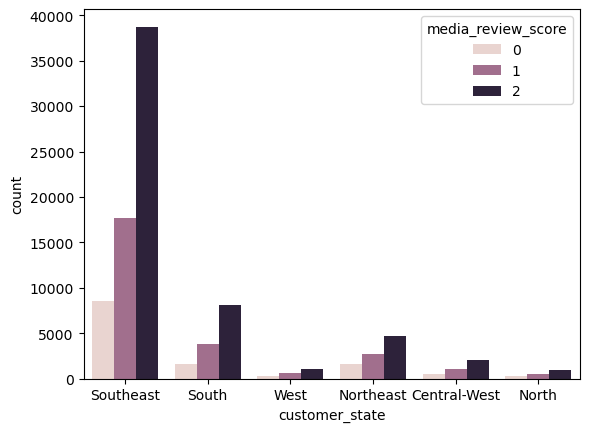

In [7]:
sns.countplot(data, x = "customer_state", hue = "media_review_score")
plt.show()

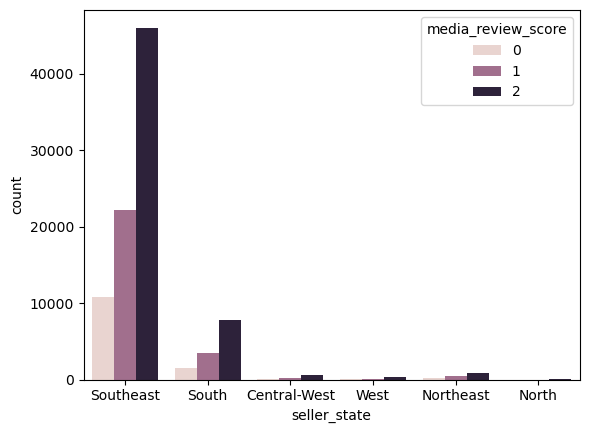

In [8]:
sns.countplot(data, x = "seller_state", hue = "media_review_score")
plt.show()

In [9]:
data.duplicated().sum()

np.int64(1342)

In [10]:
data.isna().sum()

media_review_score               0
delivered_status                 0
delay_time                       0
customer_state                   0
number_payments                  0
payment_value_sum                0
payment_type                     0
number_items                     0
total_price                      0
total_freight_value              0
total_diff_items                 0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
seller_state                     0
dtype: int64

In [11]:
data.dtypes

media_review_score                 int64
delivered_status                   int64
delay_time                         int64
customer_state                    object
number_payments                  float64
payment_value_sum                float64
payment_type                      object
number_items                     float64
total_price                      float64
total_freight_value              float64
total_diff_items                 float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
seller_state                      object
dtype: object

In [12]:
cols_int = ["number_payments","number_items","total_diff_items", "product_description_lenght", "product_photos_qty"]
data[cols_int] = data[cols_int].astype("int64")
data.dtypes

media_review_score                 int64
delivered_status                   int64
delay_time                         int64
customer_state                    object
number_payments                    int64
payment_value_sum                float64
payment_type                      object
number_items                       int64
total_price                      float64
total_freight_value              float64
total_diff_items                   int64
product_description_lenght         int64
product_photos_qty                 int64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
seller_state                      object
dtype: object

In [13]:
# # Hacer histplot mas legibles
# sns.countplot(data, x = "delivered_status", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "credit_card_payment", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "number_items", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "total_diff_items", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "product_photos_qty", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "product_category_name_english", hue = "media_review_score")
# plt.xticks(rotation=90)  # <- AHORA VERTICAL
# plt.show()

# sns.histplot(data, x = "payment_value_sum", hue = "media_review_score")
# plt.xlim(0, 500)
# plt.show()
# sns.histplot(data, x = "total_price", hue = "media_review_score")
# plt.xlim(0, 500)
# plt.show()
# sns.histplot(data, x = "total_freight_value", hue = "media_review_score")
# plt.xlim(0, 500)
# plt.show()
# sns.histplot(data, x = "product_description_lenght", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_weight_g", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_length_cm", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_height_cm", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_width_cm", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "delayed_order", hue = "media_review_score")
# plt.show()

In [14]:
data.columns

Index(['media_review_score', 'delivered_status', 'delay_time',
       'customer_state', 'number_payments', 'payment_value_sum',
       'payment_type', 'number_items', 'total_price', 'total_freight_value',
       'total_diff_items', 'product_description_lenght', 'product_photos_qty',
       'product_weight_g', 'product_length_cm', 'product_height_cm',
       'product_width_cm', 'product_category_name_english', 'seller_state'],
      dtype='object')

## Reduccion de valores

In [15]:
for col in data.columns:
    print(f"{col}: diff= {data[col].nunique()},  max= {data[col].max()},  min= {data[col].min()}")

media_review_score: diff= 3,  max= 2,  min= 0
delivered_status: diff= 2,  max= 1,  min= 0
delay_time: diff= 196,  max= 147,  min= -200
customer_state: diff= 6,  max= West,  min= Central-West
number_payments: diff= 19,  max= 29,  min= 1
payment_value_sum: diff= 26227,  max= 13664.08,  min= 9.59
payment_type: diff= 5,  max= voucher,  min= boleto
number_items: diff= 16,  max= 20,  min= 1
total_price: diff= 6720,  max= 13440.0,  min= 0.85
total_freight_value: diff= 7172,  max= 1794.96,  min= 0.0
total_diff_items: diff= 1,  max= 1,  min= 1
product_description_lenght: diff= 2944,  max= 3992,  min= 4
product_photos_qty: diff= 19,  max= 20,  min= 1
product_weight_g: diff= 2172,  max= 40425.0,  min= 0.0
product_length_cm: diff= 99,  max= 105.0,  min= 7.0
product_height_cm: diff= 102,  max= 105.0,  min= 2.0
product_width_cm: diff= 95,  max= 118.0,  min= 6.0
product_category_name_english: diff= 6,  max= Tools and Construction,  min= Electronics and Technology
seller_state: diff= 6,  max= West,  m

In [16]:
data.head()

,media_review_score,delivered_status,delay_time,customer_state,number_payments,payment_value_sum,payment_type,number_items,total_price,total_freight_value,total_diff_items,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_state
0,2,1,9,Southeast,1,72.19,credit_card,1,58.90,13.29,1,598,4,650.0,28.0,9.0,14.0,Miscellaneous and Other Items,Southeast
1,1,1,3,Southeast,1,259.83,credit_card,1,239.90,19.93,1,239,2,30000.0,50.0,30.0,40.0,Miscellaneous and Other Items,Southeast
2,2,1,14,Southeast,1,216.87,credit_card,1,199.00,17.87,1,695,2,3050.0,33.0,13.0,33.0,Home and Decoration,Southeast
3,1,1,6,Southeast,1,25.78,credit_card,1,12.99,12.79,1,480,1,200.0,16.0,10.0,15.0,Fashion and Personal Care,Southeast
4,2,1,16,Southeast,1,218.04,credit_card,1,199.90,18.14,1,409,1,3750.0,35.0,40.0,30.0,Tools and Construction,South


In [17]:
# Modificamos las medidas para obtener un volumen en cm3
data["vol"] = data["product_length_cm"] * data["product_height_cm"] * data["product_width_cm"]
data = data.drop(columns = ["product_length_cm","product_height_cm","product_width_cm"]
)

In [18]:
data["seller_southeast_state"] = np.where(data["seller_state"] == "Southeast",1,0)
data = data.drop(columns = "seller_state")

In [19]:
data["customer_southeast_state"] = np.where(data["customer_state"] == "Southeast",1,0)
data = data.drop(columns = "customer_state")

In [20]:
data["delayed_order"] = np.where(data["delay_time"] < 0,1,0)
data = data.drop(columns = "delay_time")

In [21]:
data["unique_item"] = np.where(data["total_diff_items"] == 1,1,0)
data = data.drop(columns = "total_diff_items")

In [22]:
data["multiple_payments"] = np.where(data["number_payments"] > 1,1,0)
data = data.drop(columns = "number_payments")

In [23]:
data["unique_unit"] = np.where(data["number_items"] > 1,1,0)
data = data.drop(columns = "number_items")

In [24]:
data["credit_card_payment"] = np.where(data["payment_type"] == "credit_card",1,0)
data = data.drop(columns = "payment_type")

In [25]:
data.head()

,media_review_score,delivered_status,payment_value_sum,total_price,total_freight_value,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english,vol,seller_southeast_state,customer_southeast_state,delayed_order,unique_item,multiple_payments,unique_unit,credit_card_payment
0,2,1,72.19,58.90,13.29,598,4,650.0,Miscellaneous and Other Items,3528.0,1,1,0,1,0,0,1
1,1,1,259.83,239.90,19.93,239,2,30000.0,Miscellaneous and Other Items,60000.0,1,1,0,1,0,0,1
2,2,1,216.87,199.00,17.87,695,2,3050.0,Home and Decoration,14157.0,1,1,0,1,0,0,1
3,1,1,25.78,12.99,12.79,480,1,200.0,Fashion and Personal Care,2400.0,1,1,0,1,0,0,1
4,2,1,218.04,199.90,18.14,409,1,3750.0,Tools and Construction,42000.0,0,1,0,1,0,0,1


In [26]:
data.dtypes

media_review_score                 int64
delivered_status                   int64
payment_value_sum                float64
total_price                      float64
total_freight_value              float64
product_description_lenght         int64
product_photos_qty                 int64
product_weight_g                 float64
product_category_name_english     object
vol                              float64
seller_southeast_state             int64
customer_southeast_state           int64
delayed_order                      int64
unique_item                        int64
multiple_payments                  int64
unique_unit                        int64
credit_card_payment                int64
dtype: object

In [27]:
data.isna().sum()

media_review_score               0
delivered_status                 0
payment_value_sum                0
total_price                      0
total_freight_value              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_category_name_english    0
vol                              0
seller_southeast_state           0
customer_southeast_state         0
delayed_order                    0
unique_item                      0
multiple_payments                0
unique_unit                      0
credit_card_payment              0
dtype: int64

In [28]:
data.columns

Index(['media_review_score', 'delivered_status', 'payment_value_sum',
       'total_price', 'total_freight_value', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g',
       'product_category_name_english', 'vol', 'seller_southeast_state',
       'customer_southeast_state', 'delayed_order', 'unique_item',
       'multiple_payments', 'unique_unit', 'credit_card_payment'],
      dtype='object')

In [29]:
## Doomies

In [30]:
data = pd.get_dummies(data, columns = ["product_category_name_english"])
data.columns

Index(['media_review_score', 'delivered_status', 'payment_value_sum',
       'total_price', 'total_freight_value', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'vol',
       'seller_southeast_state', 'customer_southeast_state', 'delayed_order',
       'unique_item', 'multiple_payments', 'unique_unit',
       'credit_card_payment',
       'product_category_name_english_Electronics and Technology',
       'product_category_name_english_Fashion and Personal Care',
       'product_category_name_english_Home and Decoration',
       'product_category_name_english_Leisure, Toys and Arts',
       'product_category_name_english_Miscellaneous and Other Items',
       'product_category_name_english_Tools and Construction'],
      dtype='object')

# CREACION DE MODELO GRADIENT BOOSTING

## Analisis correlacion

In [31]:
data.dtypes

media_review_score                                               int64
delivered_status                                                 int64
payment_value_sum                                              float64
total_price                                                    float64
total_freight_value                                            float64
product_description_lenght                                       int64
product_photos_qty                                               int64
product_weight_g                                               float64
vol                                                            float64
seller_southeast_state                                           int64
customer_southeast_state                                         int64
delayed_order                                                    int64
unique_item                                                      int64
multiple_payments                                                int64
unique

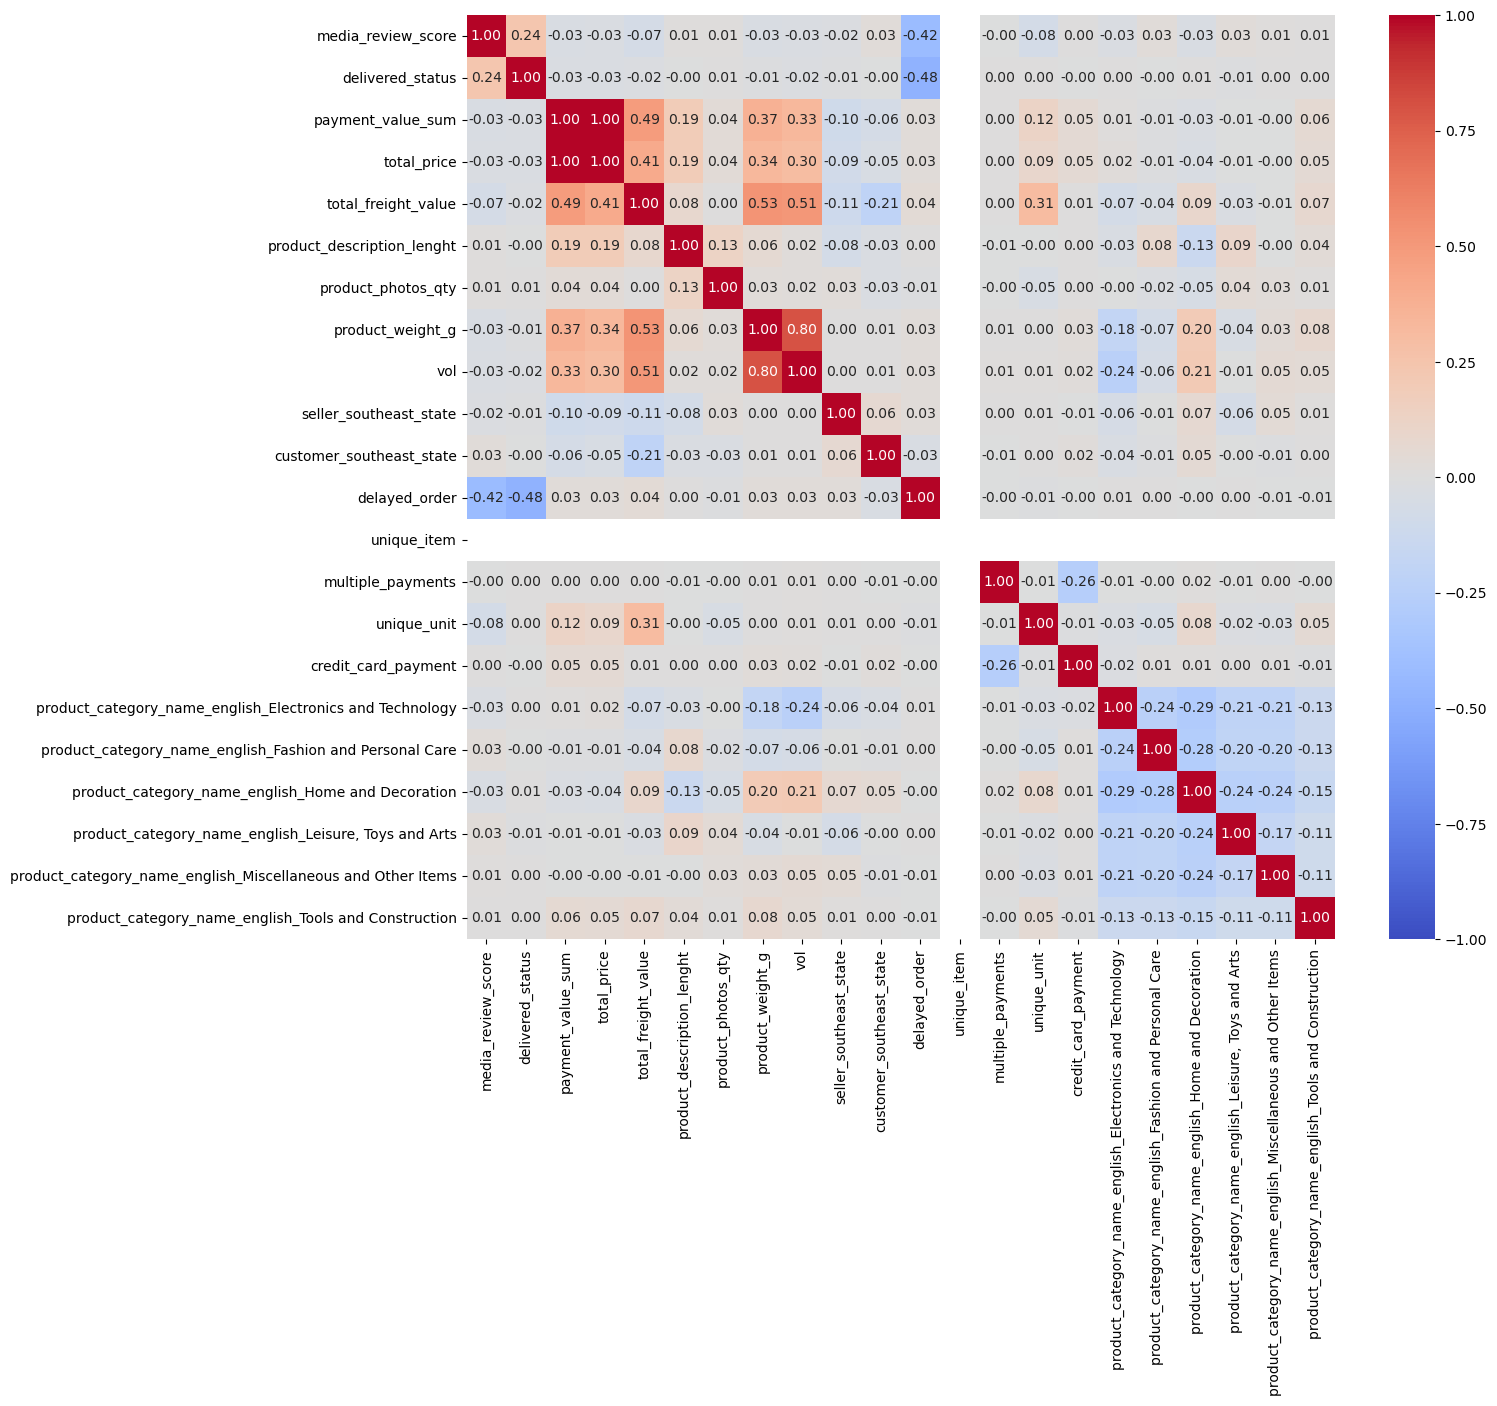

In [32]:
corr = data.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)
plt.show()

In [33]:
# Ajustamos para reducir variables intentando perder pocos datos pasando a la densidad del producto
# Eliminamos columnas con alta correlacion entre ellas, domo delivered stats y payment value sum
data["dens"] = data["product_weight_g"] / data["vol"]
data = data.drop(columns = ["payment_value_sum","product_weight_g","vol"])

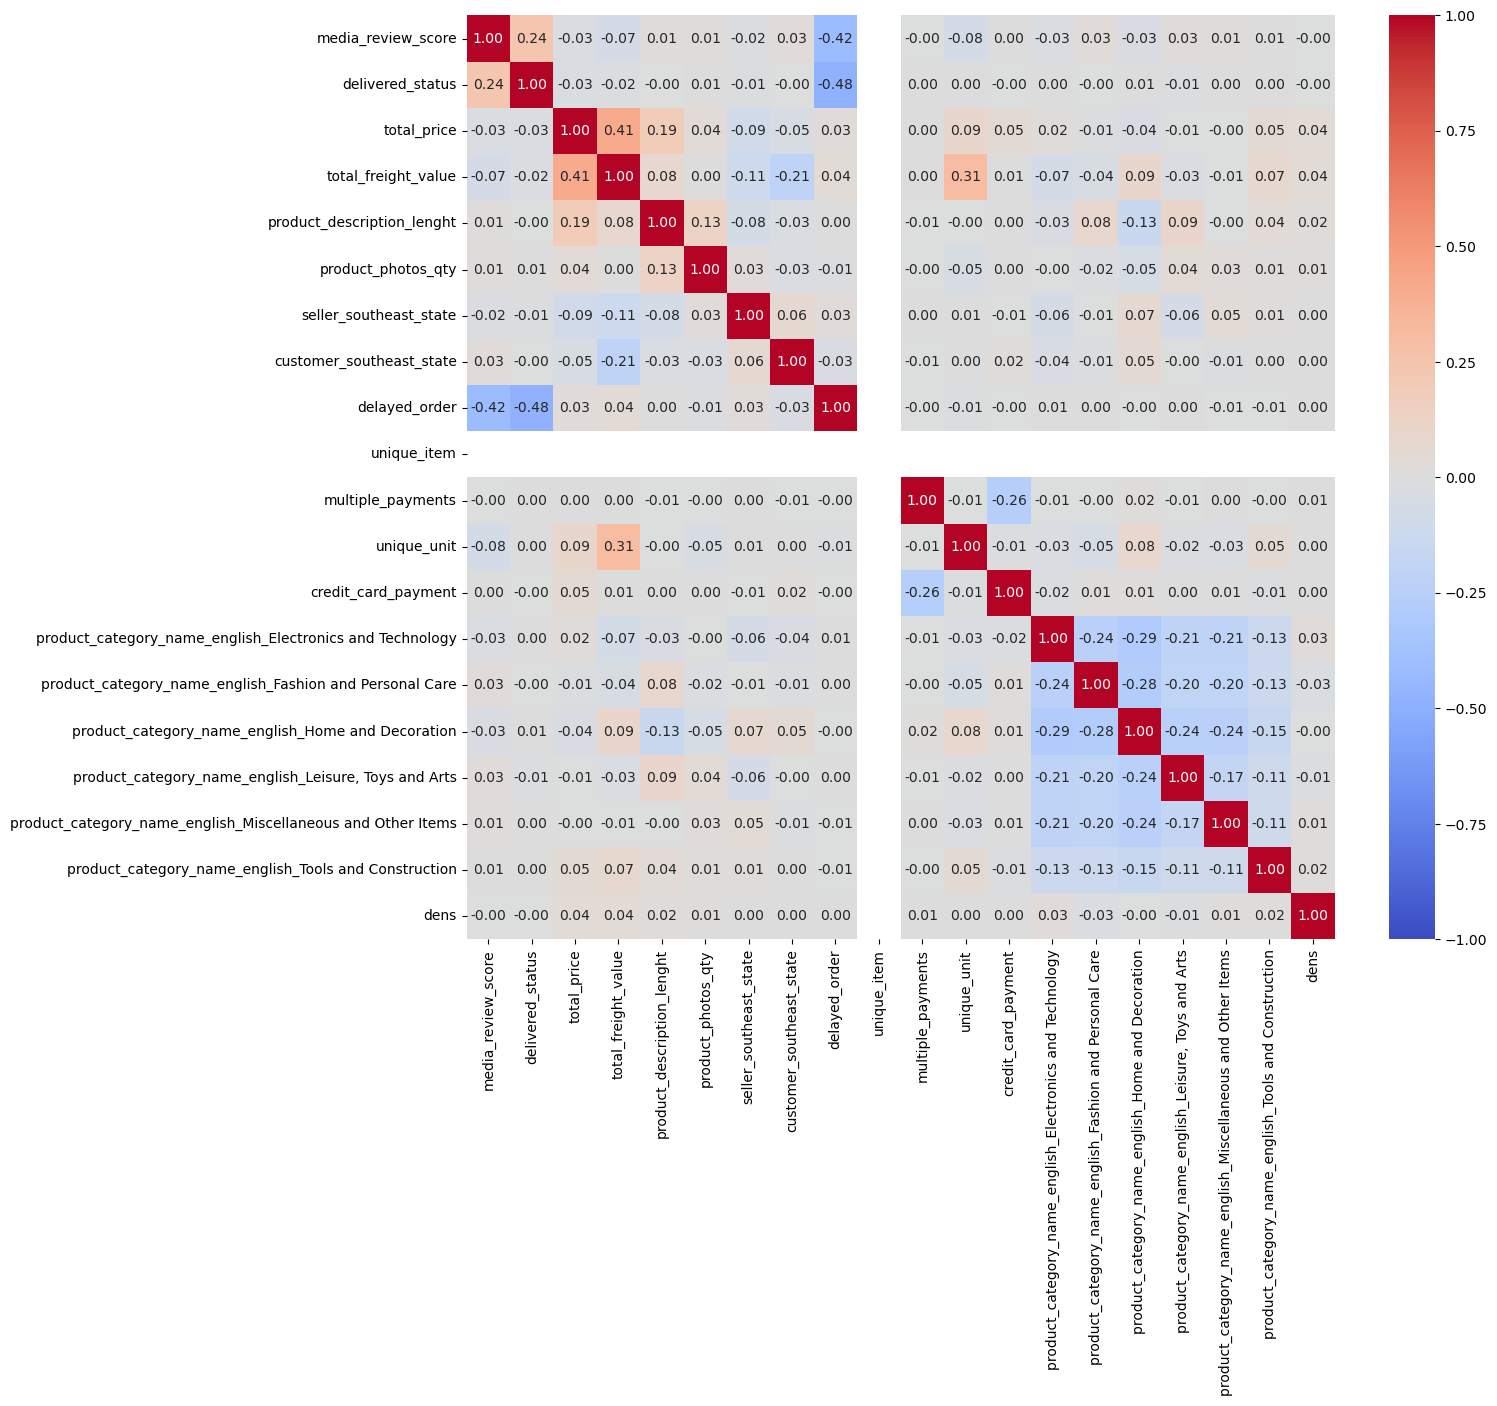

In [34]:
corr = data.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)
plt.show()

## OUTLIERS

In [35]:
data.columns

Index(['media_review_score', 'delivered_status', 'total_price',
       'total_freight_value', 'product_description_lenght',
       'product_photos_qty', 'seller_southeast_state',
       'customer_southeast_state', 'delayed_order', 'unique_item',
       'multiple_payments', 'unique_unit', 'credit_card_payment',
       'product_category_name_english_Electronics and Technology',
       'product_category_name_english_Fashion and Personal Care',
       'product_category_name_english_Home and Decoration',
       'product_category_name_english_Leisure, Toys and Arts',
       'product_category_name_english_Miscellaneous and Other Items',
       'product_category_name_english_Tools and Construction', 'dens'],
      dtype='object')

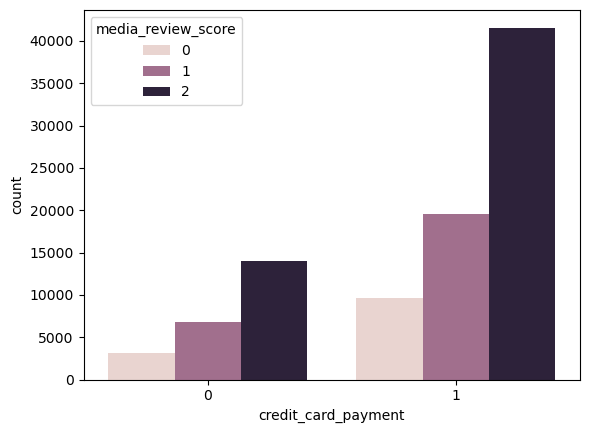

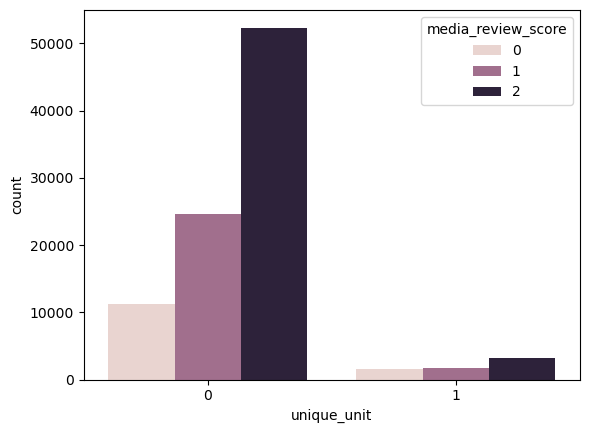

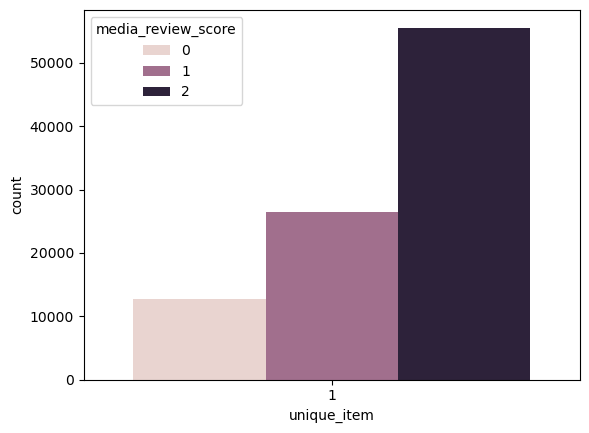

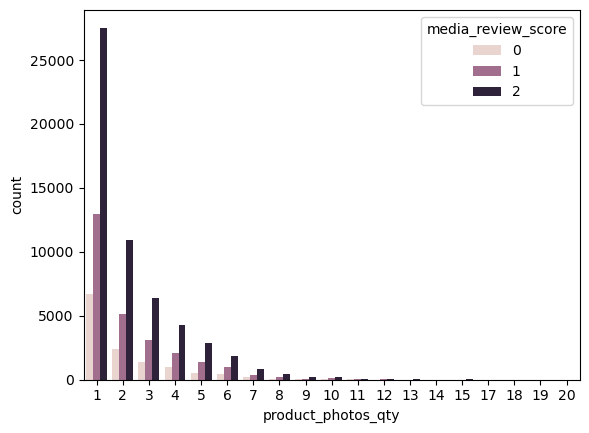

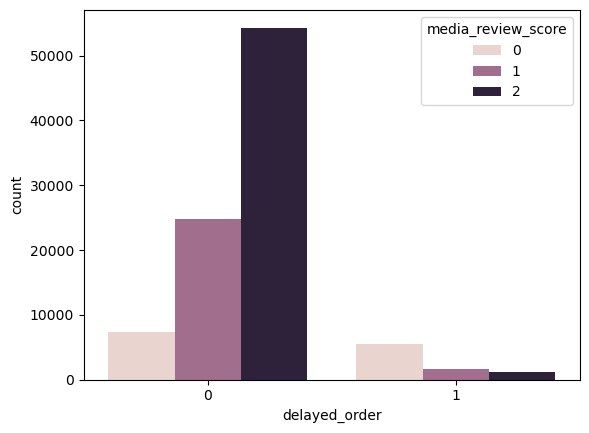

In [36]:
# Hacer histplot mas legibles
sns.countplot(data, x = "credit_card_payment", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "unique_unit", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "unique_item", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "product_photos_qty", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "delayed_order", hue = "media_review_score")
plt.show()

# sns.histplot(data, x = "total_price", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "total_freight_value", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_description_lenght", hue = "media_review_score")
# plt.show()

Posibles outliers
- product_photos_qty - 10 o mas
- total_freight_value mayor que 100
- dens tiene valores outliner grandes

Observamos que hay una gran cantidad de outliers que pertenecen a casos reales, seria recomendable clipearlos para reducir las distancias en knn?

In [37]:
# Clipping
data["product_photos_qty"] = data["product_photos_qty"].clip(upper=7)

# Winsorization
p97_description_lenght = data["product_description_lenght"].quantile(0.97)
data["product_description_lenght"] = data["product_description_lenght"].clip(upper=p97_description_lenght)
data["total_price"] = np.log1p(data["total_price"])

# Conversion logaritmica para valores muy altos
data["total_freight_value"] = np.log1p(data["total_freight_value"])
data["total_freight_value"] = data["total_freight_value"].clip(lower=4)

data["product_description_lenght"] = np.log1p(data["product_description_lenght"])
data["product_description_lenght"] = data["product_description_lenght"].clip(lower=5)

data["dens"] = np.log1p(data["dens"])

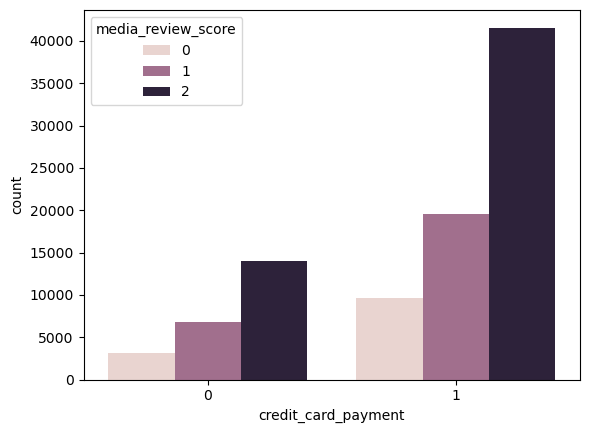

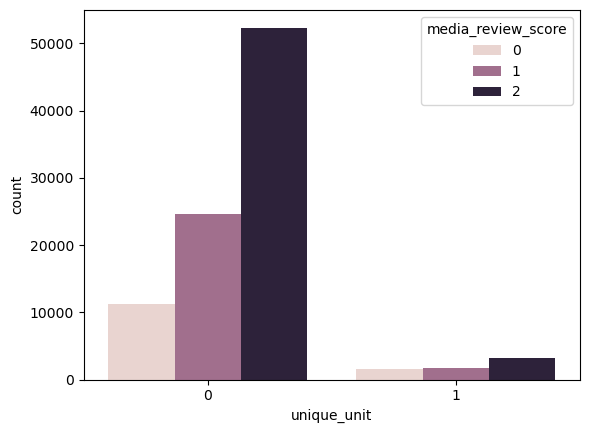

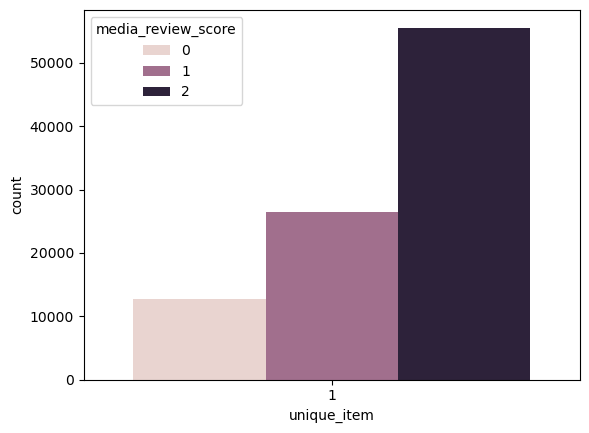

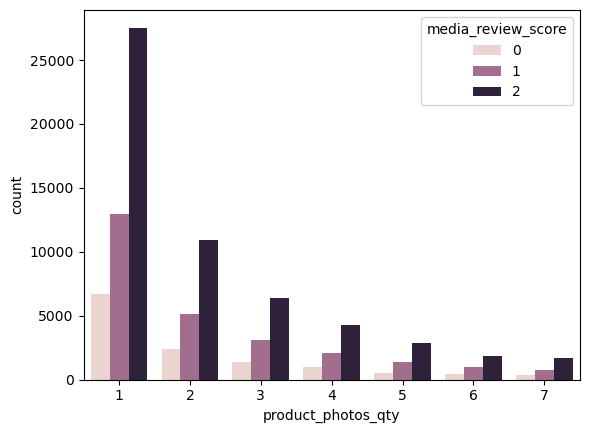

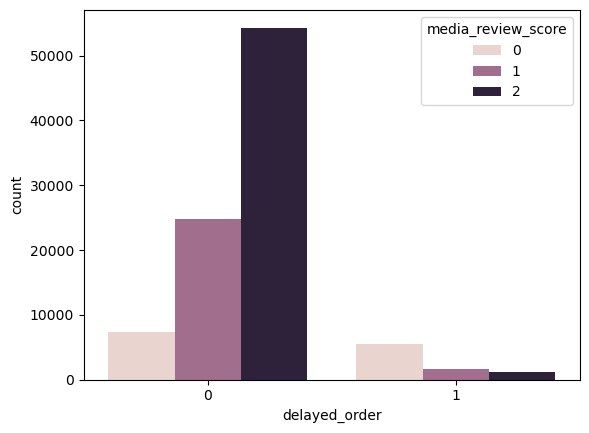

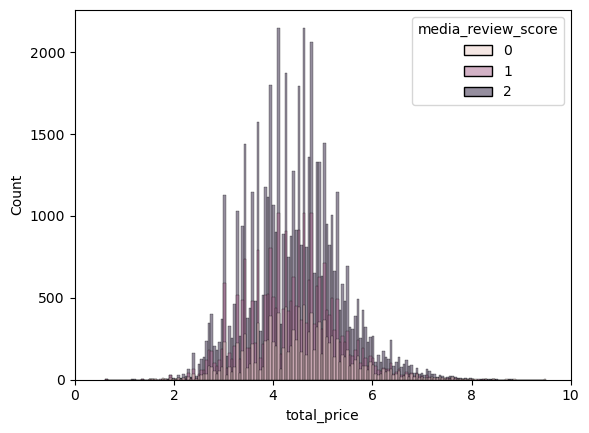

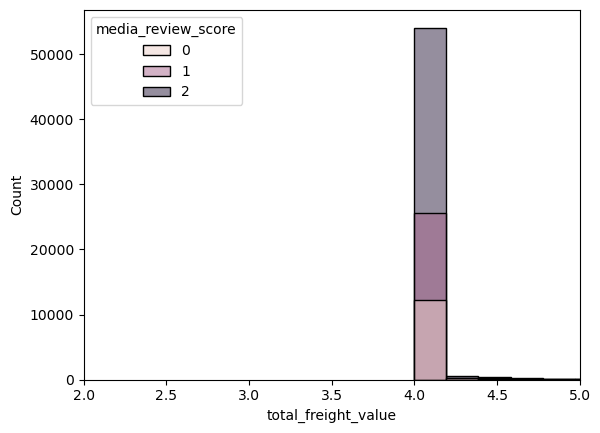

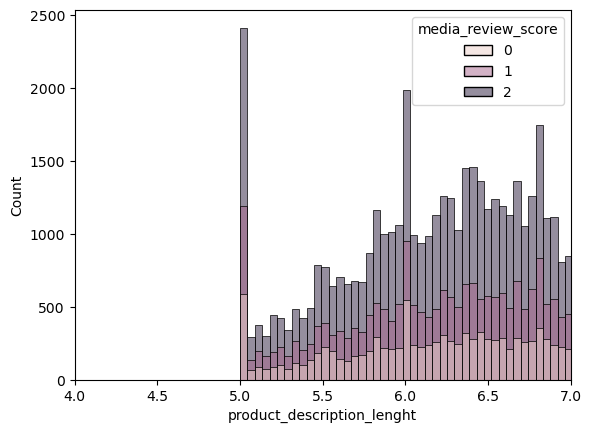

In [38]:
# Hacer histplot mas legibles
sns.countplot(data, x = "credit_card_payment", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "unique_unit", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "unique_item", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "product_photos_qty", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "delayed_order", hue = "media_review_score")
plt.show()

sns.histplot(data, x = "total_price", hue = "media_review_score")
plt.xlim(0, 10)
plt.show()
sns.histplot(data, x = "total_freight_value", hue = "media_review_score")
plt.xlim(2, 5)
plt.show()
sns.histplot(data, x = "product_description_lenght", hue = "media_review_score")
plt.xlim(4, 7)
plt.show()

## Modelo

🔹 Por qué estos valores:
- learning_rate bajo → mejor generalización
- n_estimators alto → compensar learning rate
- max_depth=3 → evita reglas demasiado específicas
- subsample < 1 → reduce overfitting (stochastic boosting)

In [39]:
# definimos funcion para generar modelos
def model_generator(X_train, X_test, y_train, y_test):

    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    real_balance = f1_score(y_test, y_pred, average="macro")
    
    stability  = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro"
    ).mean()
    return model,accuracy,real_balance,stability

In [40]:
def generate_data_train_test(X,y):
    return train_test_split(
        X, y,
        train_size = 0.75,
        test_size = 0.25
    )

In [41]:
X = data.drop(columns = "media_review_score")

### Modelo 3 variables

In [42]:
X_train, X_test, y_train, y_test = generate_data_train_test(X,y_3)
model, accuracy, real_balance, stability = model_generator(X_train, X_test, y_train, y_test)
accuracy

0.6335726351351352

In [43]:
real_balance

0.4298917725446299

In [44]:
stability

np.float64(0.4290188115297807)

# RESULTADOS

In [45]:
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)

roc_auc_score_value = roc_auc_score(
    y_test,
    y_pred_proba,
    multi_class="ovr",
    average="macro"
)

In [46]:
print(f"acc: {accuracy}    f1: {real_balance} roc_auc_score: {roc_auc_score_value}")

acc: 0.6335726351351352    f1: 0.4298917725446299 roc_auc_score: 0.6417445701190116


In [47]:
from sklearn.metrics import recall_score

sens_por_clase = recall_score(
    y_test,
    y_pred,
    average=None,
    labels=model.classes_
)

sens_por_clase

array([4.25240908e-01, 6.09106137e-04, 9.80929764e-01])

In [48]:
recall_score(y_test, y_pred, average="macro")

0.46892659259185243

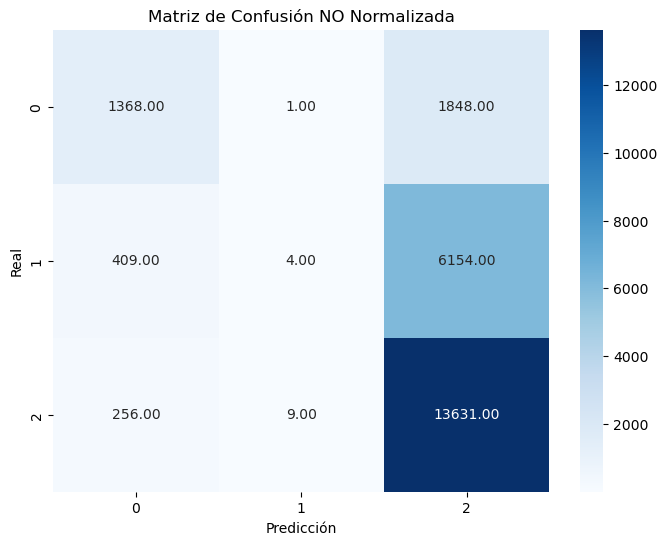

In [49]:
labels = model.classes_

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión NO Normalizada")
plt.show()

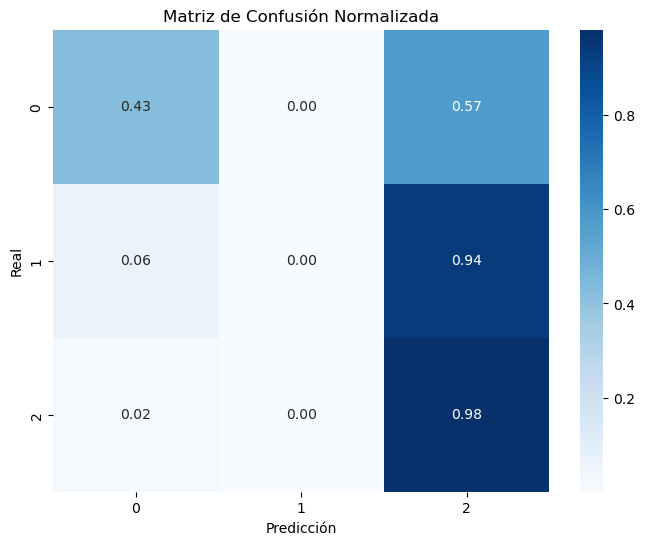

In [50]:
cm_norm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true"

)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión Normalizada")
plt.show()

In [51]:
specificity = {}

for i, cls in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    specificity[cls] = TN / (TN + FP)

print(f"({TP},{FP}")
print(f"{FN},{TN})")

specificity_mean = np.mean(list(specificity.values()))

(13631,8002
265,1782)


In [52]:
specificity[2]

np.float64(0.1821340964840556)

In [53]:
print(f"acc: {accuracy}    f1: {real_balance}   roc_auc_score: {roc_auc_score_value}   specificity_mean: {specificity_mean}   specificity_2: {specificity[2]}")

acc: 0.6335726351351352    f1: 0.4298917725446299   roc_auc_score: 0.6417445701190116   specificity_mean: 0.7163506888895649   specificity_2: 0.1821340964840556


Peso de las variables

In [54]:
importances = model.feature_importances_
features = X.columns

fi = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)
fi

,feature,importance
7,delayed_order,0.806169
18,dens,0.034960
10,unique_unit,0.034284
1,total_price,0.034224
3,product_description_lenght,0.021761
0,delivered_status,0.012927
2,total_freight_value,0.011301
14,product_category_name_english_Home and Decoration,0.008594
4,product_photos_qty,0.007218
12,product_category_name_english_Electronics and ...,0.006562


In [55]:
y_test_bin = label_binarize(y_test, classes=labels)

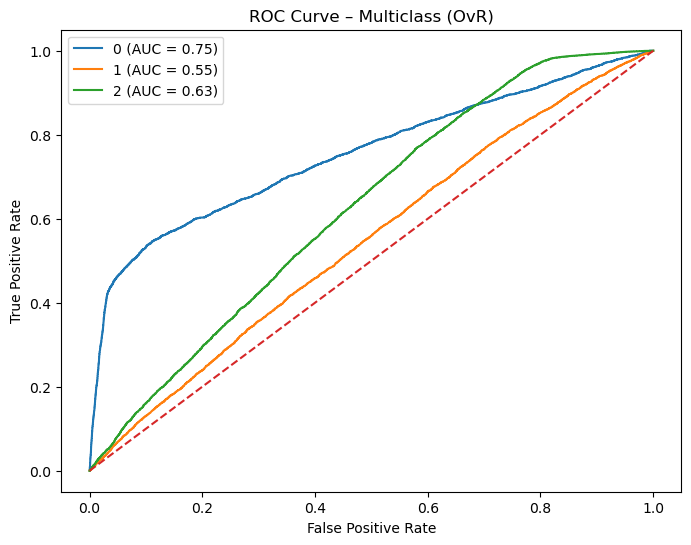

In [56]:
plt.figure(figsize=(8,6))

for i, cls in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Multiclass (OvR)")
plt.legend()
plt.show()

# MEJORA MODELO

Retiraremos las columnas que tengan valores outliners, nos quedaremso solo con los que esten entregados
- Mejora de outliers
- Extraccion de keywords de reviews